# Introduction to Data Science 2026, Week 2

Abtaal Aatif

## Exercise 4 | Junk charts

There’s a thriving community of chart enthusiasts who keep looking for statistical graphics that they find inappropriate, and which they call “junk charts”, and who often also propose ways to improve them.

1. Find at least three statistical visualizations you think are not very good and identify their problems. Copying examples from various junk chart websites is not accepted – you should find your own junk charts, out in the wild. You should be able to find good (or rather, bad) examples quite easily since a significant fraction of charts can have at least *some* issues. The examples you choose should also have different problems, e.g., try to avoid collecting three bar charts, all with problematic axes. Instead, try to find as interesting and diverse examples as you can.

2. Try to produce improved versions of the charts you selected. The data is of course often not available, but perhaps you can try to extract it, at least approximately, from the chart. Or perhaps you can simulate data that looks similar enough to make the point.



**Submit a PDF with all the charts (the ones you found and the ones you produced).**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Chart 1: "The Smartest AI Models in 2026"

Source: Visual Capitalist, 24 April 2026, https://www.visualcapitalist.com/ranked-the-smartest-ai-models-in-2026/ (data: TrackingAI, Mensa Norway test)

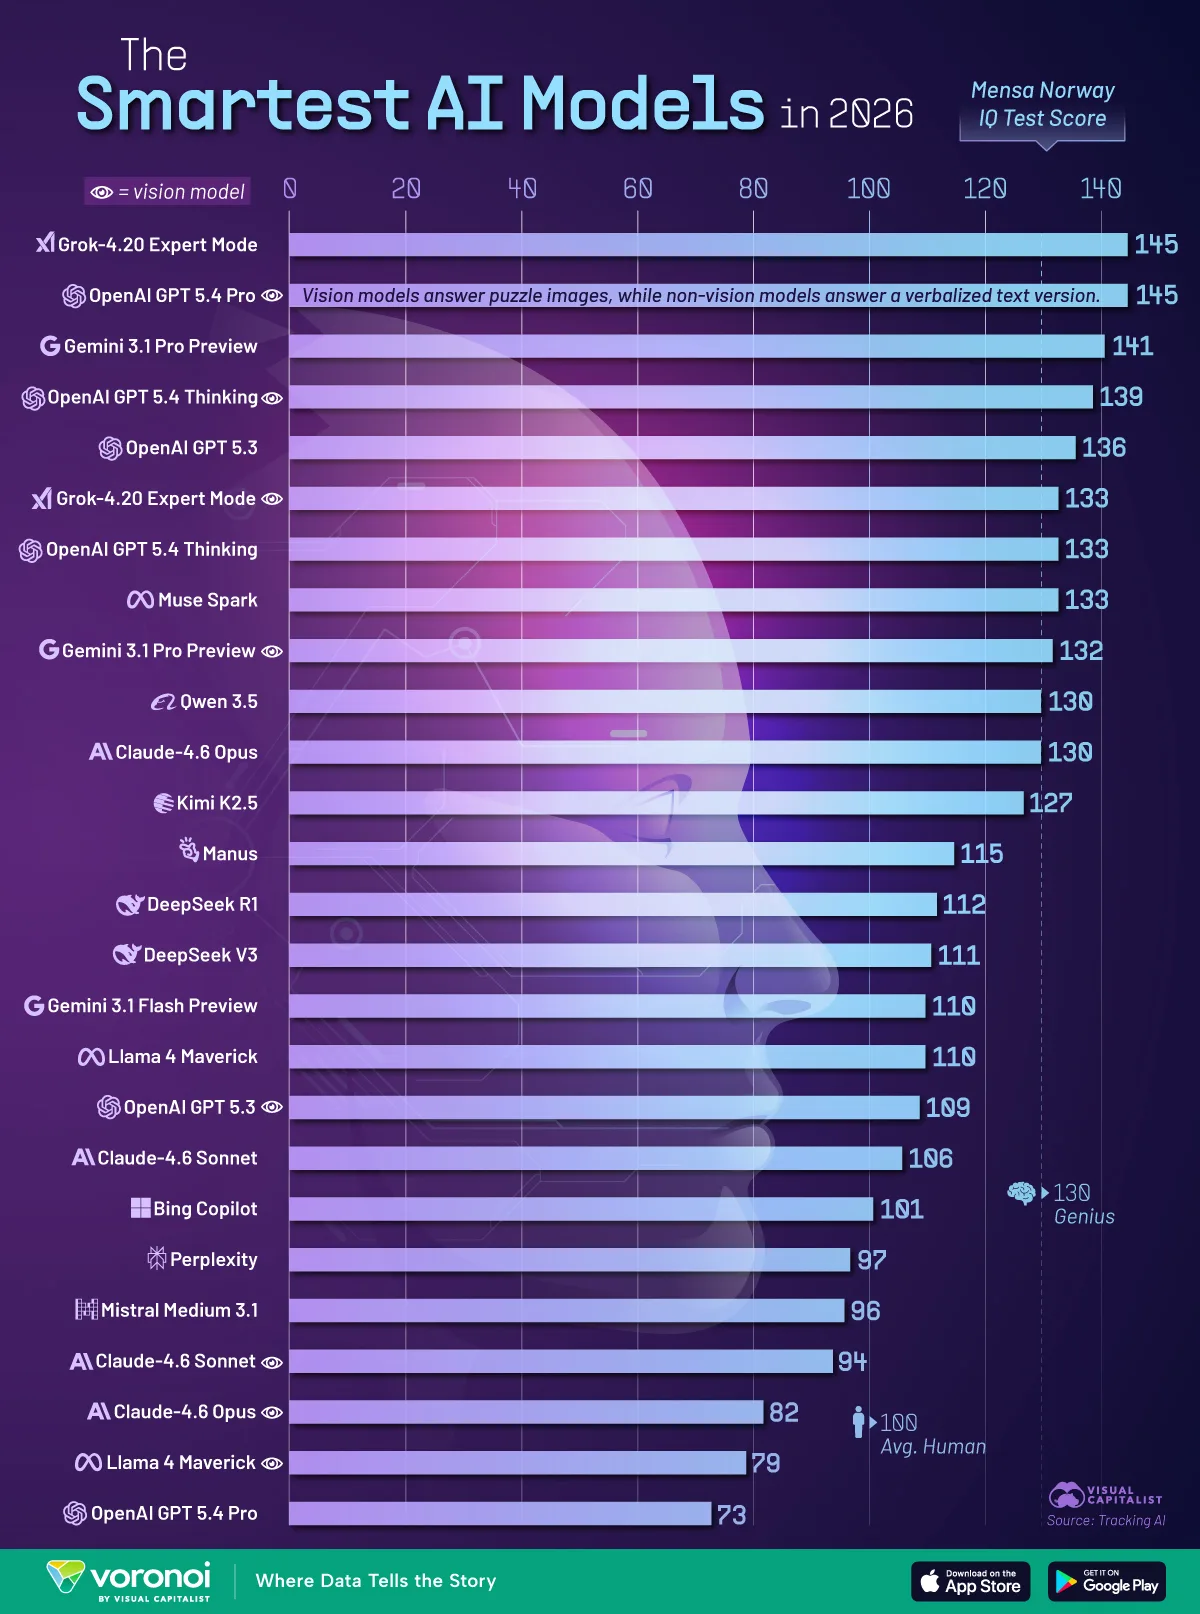

**Problems:**
- The bar lengths are misleading. Representation (length, area) should be directly proportional to the number, which is why bar charts have to start at zero. These bars do start at zero, but an IQ score has no meaningful zero (the scale is fixed so that the average is 100), so a bar twice as long does not mean twice as intelligent. Still, the text version of GPT 5.4 Pro (73) looks half as smart as the top models (145). A bar chart is the wrong choice for this kind of scale.
- Low data-ink ratio: the face illustration, the glowing gradient bars and the background add a lot of ink that shows no data. This is design variation, not data variation.
- The chart depends on a legend. Whether a score comes from the text or the image version of the test is only shown by a small eye icon that is explained in a corner, so GPT 5.4 Pro appears both first (145) and last (73) without it being obvious why. The labelling should be on the graphic itself.
- Compared to what? The most important comparison, the average human at 100, is only a floating label in the bottom corner with no line across the chart.

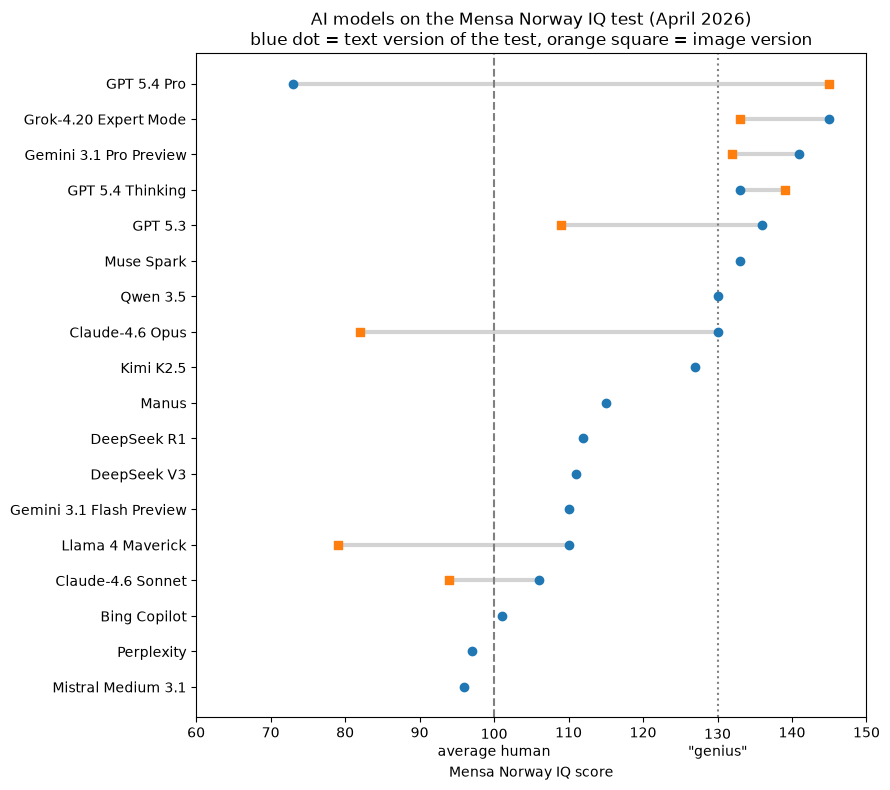

In [2]:
# Scores from the original chart. Most models were tested twice: on a text version
# of the puzzles and on the original images (vision). NaN = no vision score.
iq = pd.DataFrame({
    'model': ['Grok-4.20 Expert Mode', 'GPT 5.4 Pro', 'Gemini 3.1 Pro Preview', 'GPT 5.4 Thinking',
              'GPT 5.3', 'Muse Spark', 'Qwen 3.5', 'Claude-4.6 Opus', 'Kimi K2.5', 'Manus',
              'DeepSeek R1', 'DeepSeek V3', 'Gemini 3.1 Flash Preview', 'Llama 4 Maverick',
              'Claude-4.6 Sonnet', 'Bing Copilot', 'Perplexity', 'Mistral Medium 3.1'],
    'text':   [145, 73, 141, 133, 136, 133, 130, 130, 127, 115, 112, 111, 110, 110, 106, 101, 97, 96],
    'vision': [133, 145, 132, 139, 109, np.nan, np.nan, 82, np.nan, np.nan, np.nan, np.nan, np.nan, 79, 94,
               np.nan, np.nan, np.nan],
})
iq['best'] = iq[['text', 'vision']].max(axis=1)
iq = iq.sort_values('best')

fig, ax = plt.subplots(figsize=(9, 8))
ax.hlines(iq['model'], iq['text'], iq['vision'], color='lightgrey', linewidth=3)  # joins the two scores
ax.scatter(iq['text'], iq['model'], color='tab:blue', zorder=3)
ax.scatter(iq['vision'], iq['model'], color='tab:orange', marker='s', zorder=3)
ax.axvline(100, color='grey', linestyle='--')
ax.axvline(130, color='grey', linestyle=':')

ax.set_xticks([60, 70, 80, 90, 100, 110, 120, 130, 140, 150])
ax.set_xticklabels(['60', '70', '80', '90', '100\naverage human', '110', '120', '130\n"genius"', '140', '150'])
ax.set_xlabel('Mensa Norway IQ score')
ax.set_title('AI models on the Mensa Norway IQ test (April 2026)\n'
             'blue dot = text version of the test, orange square = image version')
plt.tight_layout()
plt.show()

**Improvement:** Each model is one row, with its two scores as dots joined by a line. Dots show the value by position instead of length, so the axis can start at 60 without distorting anything, like the graduation rate line chart in the lecture that starts at 70. The decoration is removed, the title explains the two markers instead of a separate legend, and the average human and "genius" levels are lines across the whole chart, labelled on the axis. This also shows something the original hides: for several models the gap between the text and image versions of the test is bigger than the differences between most of the models.

### Chart 2: Alphabet (GOOGL) GF Value chart

Source: GuruFocus via TradingView News, 9 September 2026, https://www.tradingview.com/news/gurufocus:e87f0e463094b:0-alphabet-drops-3-after-google-commits-13-billion-to-finland-ai/

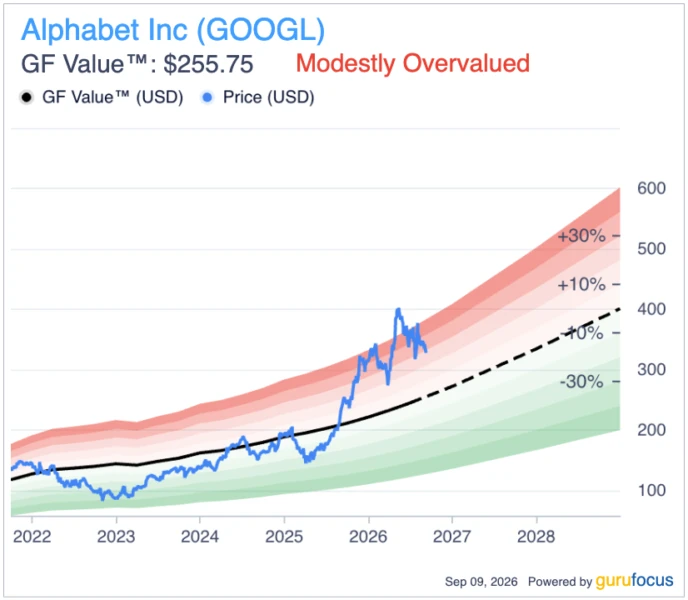

**Problems:**
- Above all else, show the data. About a third of the chart (Sep 2026 to 2028) is not data but GuruFocus's projection of its own GF Value, drawn just as prominently as the real history. Only a dashed line hints at this and the legend does not mention it, a bit like the NASA example where the important information was in the fine print.
- Red and green: the bands use red for "overvalued" and green for "undervalued". Red and green are hard to tell apart for colour-blind readers, and they carry a good vs bad connotation, which here quietly turns the chart into a buy/sell judgement.
- Unclear labelling and a lot of non-data ink: six shades of coloured bands fill most of the chart, their labels (+30%, +10%, -10%, -30%) float between the bands so it is unclear what they refer to, "-10%" sits on top of the dashed line, and the y-axis has no unit.

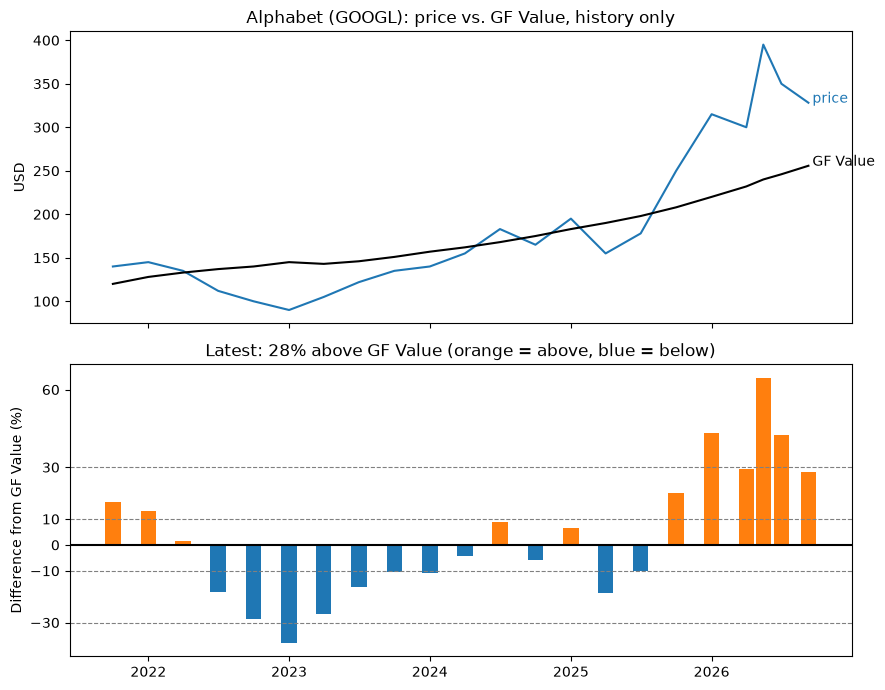

In [3]:
# Values read off the original chart by eye (approximate), except the last point,
# which is from the article: price $328.20 and GF Value $255.75 on 9 Sep 2026
googl = pd.DataFrame({
    'date': ['2021-10-01', '2022-01-01', '2022-04-01', '2022-07-01', '2022-10-01', '2023-01-01',
             '2023-04-01', '2023-07-01', '2023-10-01', '2024-01-01', '2024-04-01', '2024-07-01',
             '2024-10-01', '2025-01-01', '2025-04-01', '2025-07-01', '2025-10-01', '2026-01-01',
             '2026-04-01', '2026-05-15', '2026-07-01', '2026-09-09'],
    'price':    [140, 145, 135, 112, 100, 90, 105, 122, 135, 140, 155, 183,
                 165, 195, 155, 178, 250, 315, 300, 395, 350, 328.20],
    'gf_value': [120, 128, 133, 137, 140, 145, 143, 146, 151, 157, 162, 168,
                 175, 183, 190, 198, 208, 220, 232, 240, 246, 255.75],
})
googl['date'] = pd.to_datetime(googl['date'])
googl['diff'] = (googl['price'] / googl['gf_value'] - 1) * 100  # % above (+) or below (-) GF Value

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

# Top: price and GF Value, with the names written at the end of each line
ax1.plot(googl['date'], googl['price'], color='tab:blue')
ax1.plot(googl['date'], googl['gf_value'], color='black')
ax1.text(googl['date'].iloc[-1], googl['price'].iloc[-1], ' price', color='tab:blue')
ax1.text(googl['date'].iloc[-1], googl['gf_value'].iloc[-1], ' GF Value')
ax1.margins(x=0.12)  # extra space on the right for the line labels
ax1.set_ylabel('USD')
ax1.set_title('Alphabet (GOOGL): price vs. GF Value, history only')

# Bottom: the difference as bars (orange = above GF Value, blue = below)
colors = ['tab:orange' if d > 0 else 'tab:blue' for d in googl['diff']]
ax2.bar(googl['date'], googl['diff'], width=40, color=colors)
ax2.axhline(0, color='black')
for level in [-30, -10, 10, 30]:
    ax2.axhline(level, color='grey', linestyle='--', linewidth=0.8)
ax2.set_yticks([-30, -10, 0, 10, 30, 60])
ax2.set_ylabel('Difference from GF Value (%)')
ax2.set_title('Latest: 28% above GF Value (orange = above, blue = below)')

plt.tight_layout()
plt.show()

**Improvement:** The projection is removed, so everything shown is real data, and the y-axis has a unit. The bottom panel shows directly what the "overvalued" verdict is about: how many percent the price is above or below GF Value, as bars that start at zero, with the ±10% and ±30% levels as simple lines. Orange and blue replace red and green, and the two lines in the top panel are labelled at their ends instead of in a legend.

### Chart 3: Athletic Apparel Companies, Indexed New Customers

Source: Bloomberg Second Measure, 1 October 2020, https://secondmeasure.com/datapoints/gymsharks-new-customer-acquisition-is-devouring-the-competition/

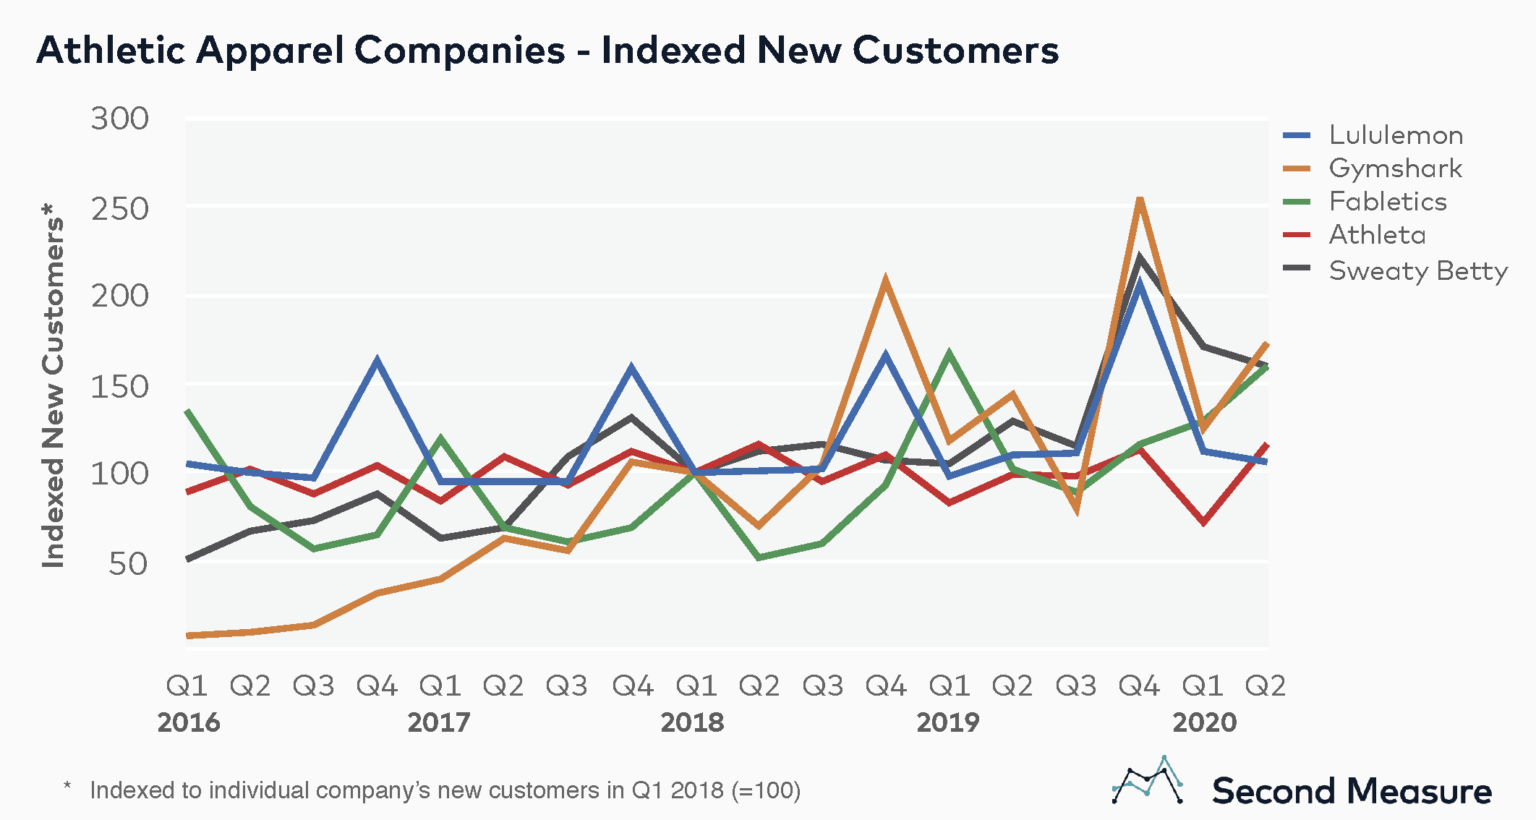

**Problems:**
- Compared to what? Every company is indexed to its own Q1 2018 (= 100), so the chart only compares each company with itself and hides how big the companies are. According to the same article, Gymshark had only 3% of the five brands' 2019 sales, compared with 56% for Lululemon, but on the chart Gymshark looks just as important. This is the kind of switch between the raw figure and the conclusion that Huff warns about: from indexed growth numbers to a headline saying Gymshark is "devouring the competition".
- Five overlapping lines can only be told apart through the legend, and the legend order does not even match the order of the lines. The labelling should be on the graphic itself.
- The Q4 holiday spikes are the most visible thing in the chart and hide the underlying trends. The Akava unemployment chart in the lecture handles this by drawing a smoothed trend line on top of the raw values.

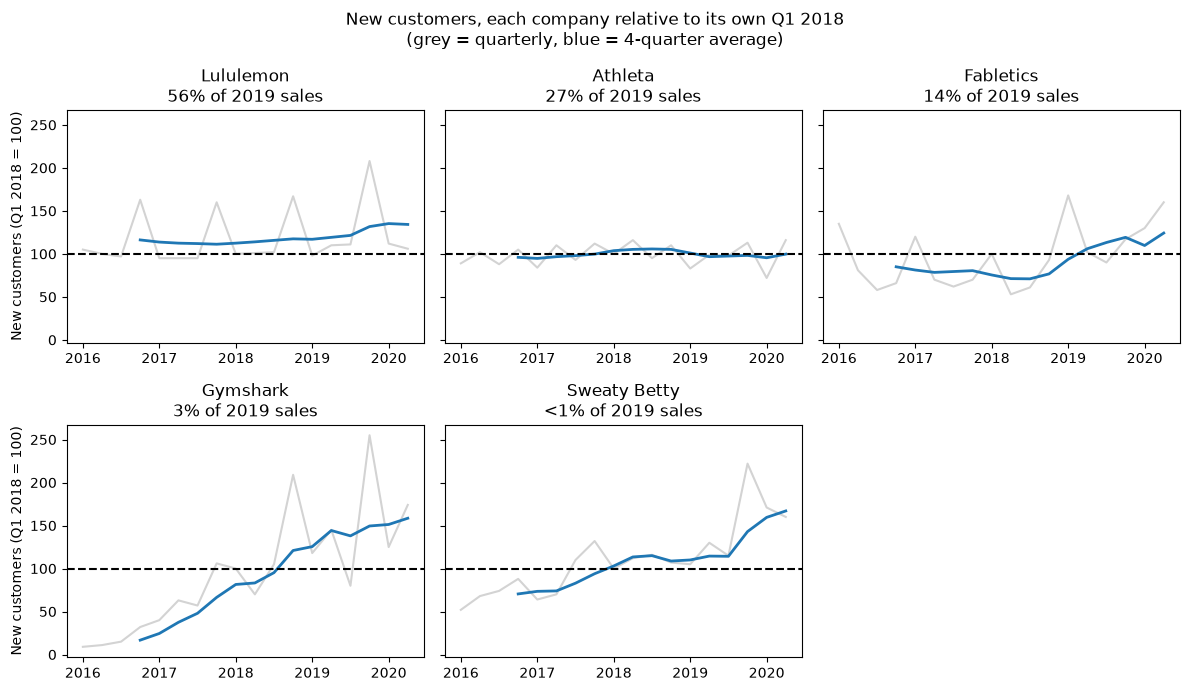

In [4]:
# New customers indexed to each company's own Q1 2018 (= 100), read off the
# original chart by eye (approximate). One value per quarter, Q1 2016 to Q2 2020.
customers = pd.DataFrame({
    'Lululemon':    [105, 100, 97, 163, 95, 95, 95, 160, 100, 101, 102, 167, 98, 110, 111, 208, 112, 106],
    'Athleta':      [89, 102, 88, 105, 84, 110, 93, 112, 100, 116, 95, 110, 83, 99, 98, 113, 72, 116],
    'Fabletics':    [135, 81, 58, 66, 120, 70, 62, 70, 100, 53, 61, 93, 168, 102, 90, 117, 130, 160],
    'Gymshark':     [9, 11, 15, 32, 40, 63, 57, 106, 100, 70, 105, 209, 118, 145, 80, 255, 125, 174],
    'Sweaty Betty': [52, 68, 74, 88, 64, 70, 110, 132, 100, 112, 116, 107, 105, 130, 115, 222, 171, 160],
})
customers.index = np.arange(2016, 2020.5, 0.25)  # quarters as years: 2016.0, 2016.25, ...

# Share of the five brands' combined 2019 US sales, from the same article
shares = ['56%', '27%', '14%', '3%', '<1%']

# One small plot per company, all with the same y-axis (2 rows x 3 columns, last spot left empty)
fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharey=True)
axes = axes.flatten()
axes[5].axis('off')
for i, company in enumerate(customers.columns):
    axes[i].plot(customers[company], color='lightgrey')
    axes[i].plot(customers[company].rolling(4).mean(), color='tab:blue', linewidth=2)  # average of last 4 quarters
    axes[i].axhline(100, color='black', linestyle='--')
    axes[i].set_title(company + '\n' + shares[i] + ' of 2019 sales')

axes[0].set_ylabel('New customers (Q1 2018 = 100)')
axes[3].set_ylabel('New customers (Q1 2018 = 100)')
fig.suptitle('New customers, each company relative to its own Q1 2018\n(grey = quarterly, blue = 4-quarter average)')
plt.tight_layout()
plt.show()

**Improvement:** Small multiples: each company gets its own panel on the same y-axis, so nothing overlaps and each panel is labelled directly with the company name. Like in the Akava example, a 4-quarter average shows the trend, with the quarterly values kept in light grey. The absolute customer numbers are not published, so the index can't be undone, but each panel title now answers "compared to what?" with the brand's share of 2019 sales, which shows that Gymshark's fast growth starts from a very small base.